<a href="https://colab.research.google.com/github/lamirabbasl/testtt/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *question 1:*

In [ ]:
import pandas as pd
from google.colab import files

df = pd.read_csv("crime.csv")

correlation_matrix = df.corr()

highest_corr_with_crmrte = correlation_matrix['crmrte'].abs().sort_values(ascending=False)

print("\nVariables with the highest correlation with crmrte:")
print(highest_corr_with_crmrte.head(5)[1:])



Variables with the highest correlation with crmrte:
density    0.694072
urban      0.559530
wfed       0.437157
west       0.360492
Name: crmrte, dtype: float64


# ***question 2:***

In [ ]:
import pandas as pd
import statsmodels.api as sm

crime_data_clean = df.dropna().copy()
crime_data_clean['year'] = crime_data_clean['year'].astype('category')

X = crime_data_clean.drop(['crmrte', 'county'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = crime_data_clean['crmrte']

X_sm = sm.add_constant(X)

model_full = sm.OLS(y, X_sm.astype(float)).fit()
print(model_full.summary())

taxpc_coef = model_full.params.get('taxpc', 'Not in model')
urban_coef = model_full.params.get('urban', 'Not in model')

print(f"\nCoefficient for taxpc: {taxpc_coef}")
print(f"Coefficient for urban: {urban_coef}")

f_pvalue = model_full.f_pvalue
print(f"\nF-test p-value: {f_pvalue}")
if f_pvalue < 0.05:
    print("There is a statistically significant relationship between predictors and response.")
else:
    print("No statistically significant relationship between predictors and response.")

                            OLS Regression Results                            
Dep. Variable:                 crmrte   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     63.56
Date:                Tue, 11 Nov 2025   Prob (F-statistic):          9.81e-157
Time:                        13:10:45   Log-Likelihood:                 2058.0
No. Observations:                 630   AIC:                            -4060.
Df Residuals:                     602   BIC:                            -3936.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0042      0.006      0.687      0.4

# **question 3:**

--- Reduced Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                 crmrte   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     106.5
Date:                Tue, 11 Nov 2025   Prob (F-statistic):          6.28e-165
Time:                        13:10:45   Log-Likelihood:                 2052.2
No. Observations:                 630   AIC:                            -4070.
Df Residuals:                     613   BIC:                            -3995.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       

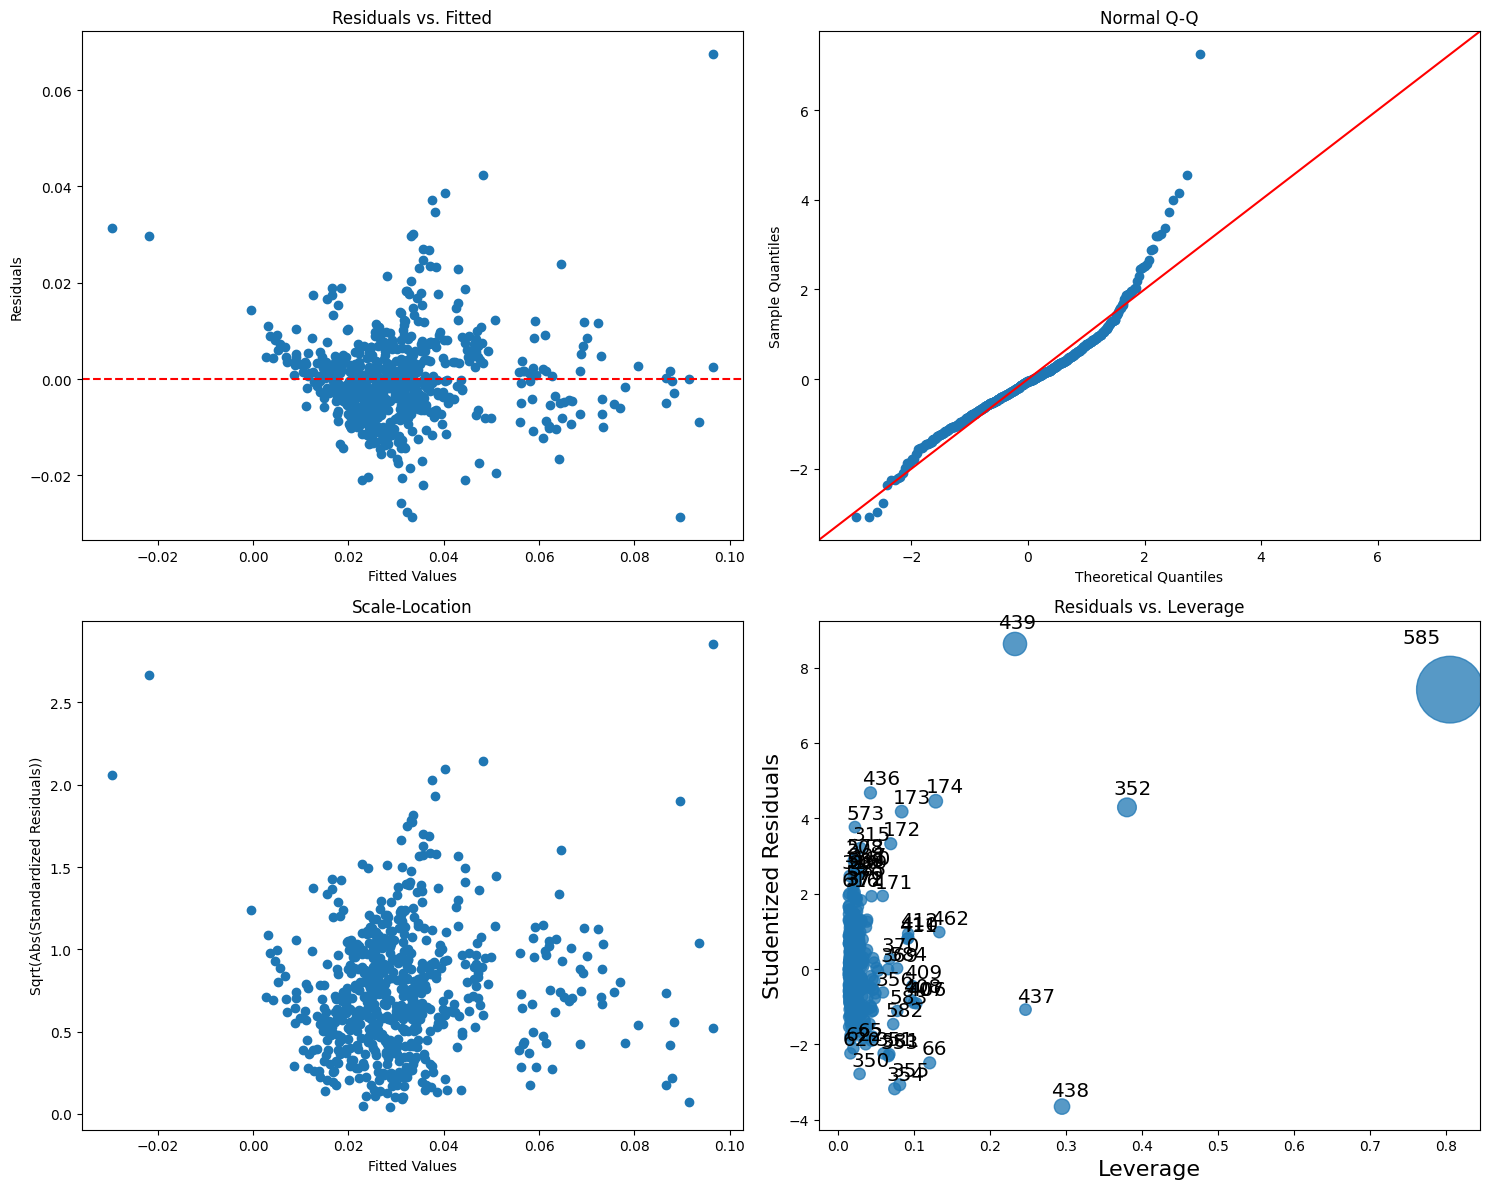

\n(b) Number of outliers (|standardized residual| > 3): 12
Number of high leverage points (>10x average leverage): 3
\n(c) Coefficient of taxpc in full model: 0.000116
Coefficient of taxpc in reduced model: 0.000095
\n(d) Variance Inflation Factor (VIF):
    feature        VIF
0    prbarr   5.098932
1   prbconv   1.575968
2     polpc   2.128270
3   density   2.918058
4     taxpc   8.425440
5      west   3.247780
6   central   2.848900
7  pctmin80   7.095300
8      wfed  30.012835
9   pctymle  10.635160


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

df = pd.read_csv("crime.csv")

formula_full = 'crmrte ~ ' + ' + '.join(df.columns.drop(['crmrte', 'county']))
formula_full = formula_full.replace('year', 'C(year)')
model_full = smf.ols(formula=formula_full, data=df).fit()

significant_vars = model_full.pvalues[model_full.pvalues < 0.05].index.tolist()
significant_predictors = [var for var in significant_vars if 'C(year)' not in var and 'Intercept' not in var]
new_formula = 'crmrte ~ C(year) + ' + ' + '.join(significant_predictors)

model_reduced = smf.ols(formula=new_formula, data=df).fit()
print("--- Reduced Model Summary ---")
print(model_reduced.summary())

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fitted_vals = model_reduced.fittedvalues
residuals = model_reduced.resid
axes[0, 0].scatter(fitted_vals, residuals)
axes[0, 0].set_title("Residuals vs. Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].axhline(0, color='red', linestyle='--')

sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 1])

axes[0, 1].set_title("Normal Q-Q")
axes[1, 0].scatter(fitted_vals, np.sqrt(np.abs(model_reduced.get_influence().resid_studentized_internal)))
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("Sqrt(Abs(Standardized Residuals))")

sm.graphics.influence_plot(model_reduced, ax=axes[1, 1], criterion="Cooks")
axes[1, 1].set_title("Residuals vs. Leverage")
plt.tight_layout()
plt.show()

influence = model_reduced.get_influence()
standardized_residuals = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
p = len(model_reduced.params) -1
n = len(df)
avg_leverage = (p + 1) / n
outliers = np.sum(np.abs(standardized_residuals) > 3)
high_leverage_points = np.sum(leverage > 10 * avg_leverage)
print(f"\\n(b) Number of outliers (|standardized residual| > 3): {outliers}")
print(f"Number of high leverage points (>10x average leverage): {high_leverage_points}")


taxpc_coef_full = model_full.params['taxpc']
taxpc_coef_reduced = model_reduced.params['taxpc']
print(f"\\n(c) Coefficient of taxpc in full model: {taxpc_coef_full:.6f}")
print(f"Coefficient of taxpc in reduced model: {taxpc_coef_reduced:.6f}")


from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[significant_predictors]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\\n(d) Variance Inflation Factor (VIF):")
print(vif_data)


# **question 4:**

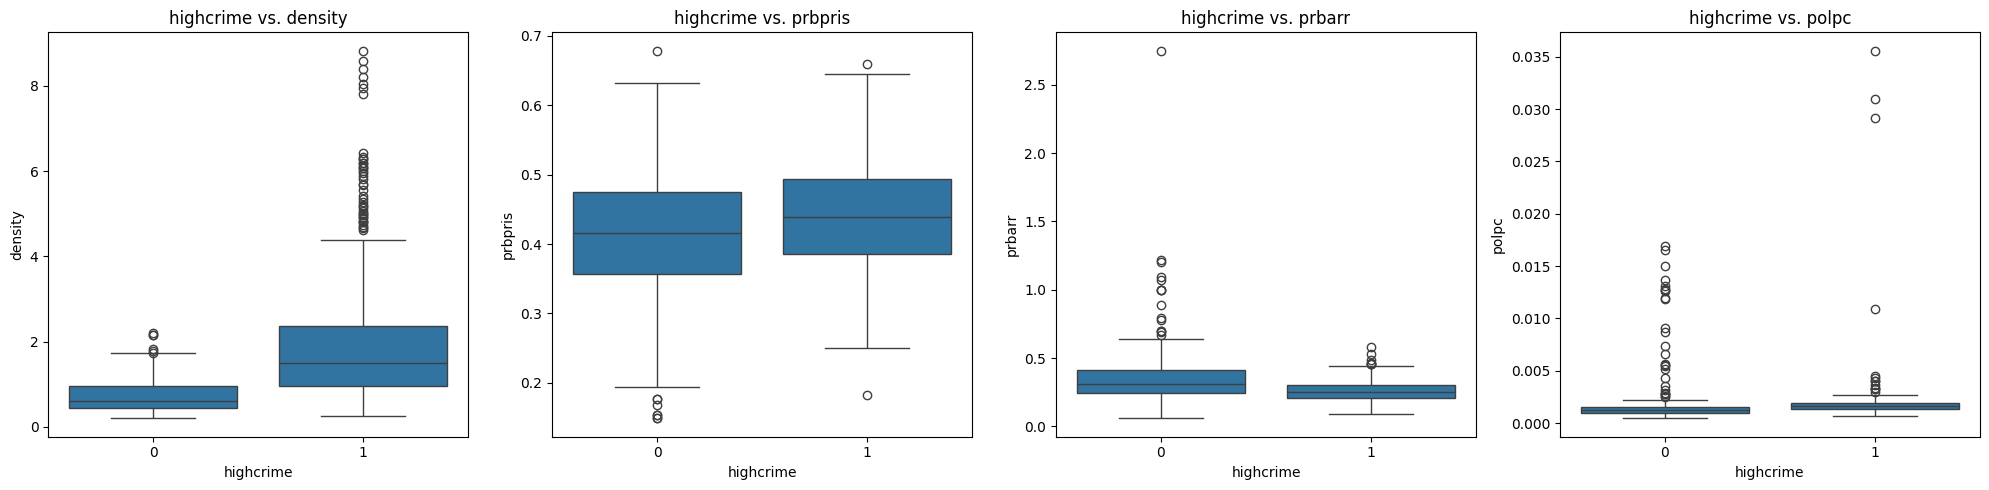

\n(b) Logistic Regression Test Errors:
  Cut-off 0.4: 0.250
  Cut-off 0.5: 0.250
  Cut-off 0.6: 0.272
\n(c) LDA Test Errors:
  Cut-off 0.4: 0.250
  Cut-off 0.5: 0.272
  Cut-off 0.6: 0.289
\n(d) QDA Test Errors:
  Cut-off 0.4: 0.239
  Cut-off 0.5: 0.267
  Cut-off 0.6: 0.256
\n(e) KNN Test Errors:
  K=1: 0.289
  K=5: 0.250
  K=10: 0.267
  K=20: 0.250
  K=50: 0.244


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


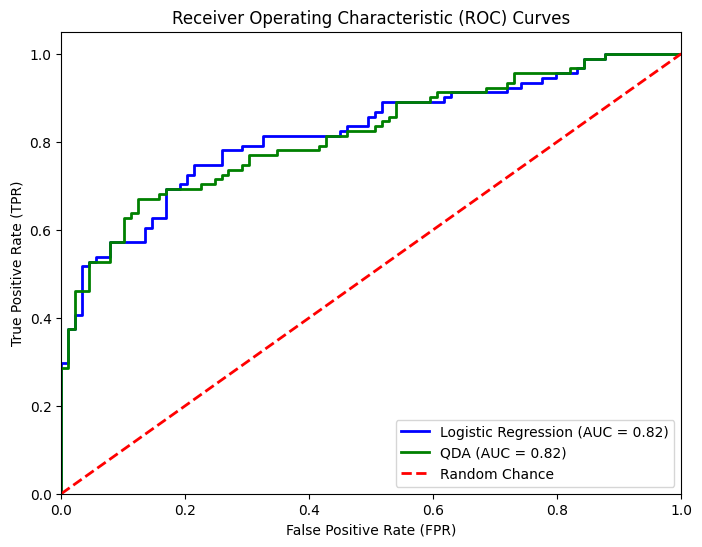

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc

df = pd.read_csv("crime.csv")

median_crmrte = df['crmrte'].median()
df['highcrime'] = (df['crmrte'] > median_crmrte).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
predictors = ['density', 'prbpris', 'prbarr', 'polpc']
for i, predictor in enumerate(predictors):
    sns.boxplot(x='highcrime', y=predictor, data=df, ax=axes[i])
    axes[i].set_title(f'highcrime vs. {predictor}')
plt.tight_layout()
plt.show()

train_df = df[df['year'] < 86]
test_df = df[df['year'] >= 86]
X_train = train_df[predictors]
y_train = train_df['highcrime']
X_test = test_df[predictors]
y_test = test_df['highcrime']

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
probs_log = log_reg.predict_proba(X_test)[:, 1]

print("\\n(b) Logistic Regression Test Errors:")
for cutoff in [0.4, 0.5, 0.6]:
    preds = (probs_log > cutoff).astype(int)
    error = np.mean(preds != y_test)
    print(f"  Cut-off {cutoff}: {error:.3f}")

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
probs_lda = lda.predict_proba(X_test)[:, 1]
print("\\n(c) LDA Test Errors:")
for cutoff in [0.4, 0.5, 0.6]:
    preds = (probs_lda > cutoff).astype(int)
    error = np.mean(preds != y_test)
    print(f"  Cut-off {cutoff}: {error:.3f}")

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
probs_qda = qda.predict_proba(X_test)[:, 1]
print("\\n(d) QDA Test Errors:")
for cutoff in [0.4, 0.5, 0.6]:
    preds = (probs_qda > cutoff).astype(int)
    error = np.mean(preds != y_test)
    print(f"  Cut-off {cutoff}: {error:.3f}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\\n(e) KNN Test Errors:")
for k in [1, 5, 10, 20, 50]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    error = np.mean(preds != y_test)
    print(f"  K={k}: {error:.3f}")

fpr_log, tpr_log, _ = roc_curve(y_test, probs_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_qda, tpr_qda, _ = roc_curve(y_test, probs_qda)
roc_auc_qda = auc(fpr_qda, tpr_qda)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_qda, tpr_qda, color='green', lw=2, label=f'QDA (AUC = {roc_auc_qda:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()


# **question 5:**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("crime.csv")
median_crmrte = df['crmrte'].median()
df['highcrime'] = (df['crmrte'] > median_crmrte).astype(int)

predictors = ['density', 'prbpris', 'prbarr', 'polpc']
X = df[predictors]
y = df['highcrime']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()

loocv = LeaveOneOut()
loocv_scores = cross_val_score(model, X_scaled, y, cv=loocv, scoring='accuracy')
loocv_error = 1 - np.mean(loocv_scores)
print(f"Leave-One-Out Cross-Validation (LOOCV) error: {loocv_error:.3f}")

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
kfold_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')
kfold_error = 1 - np.mean(kfold_scores)
print(f"5-Fold Cross-Validation error: {kfold_error:.3f}")

n_iterations = 100
bootstrap_errors = []
for i in range(n_iterations):

    X_boot, y_boot = resample(X_scaled, y, random_state=i)
    kfold_boot = KFold(n_splits=5, shuffle=True, random_state=1)
    scores = cross_val_score(model, X_boot, y_boot, cv=kfold_boot, scoring='accuracy')
    bootstrap_errors.append(1 - np.mean(scores))

accuracy_measure = np.std(bootstrap_errors)
print(f"Bootstrap measure of accuracy (std dev) for 5-fold CV error: {accuracy_measure:.3f}")


Leave-One-Out Cross-Validation (LOOCV) error: 0.244
5-Fold Cross-Validation error: 0.248
Bootstrap measure of accuracy (std dev) for 5-fold CV error: 0.017
